# SVF Preliminary Results: Embedding-Based Semantic Verbal Fluency Metrics

This notebook computes KB-BERT embedding metrics for Semantic Verbal Fluency (SVF) animal-naming responses,
and compares count-based totals against embedding-based similarity measures across diagnostic groups.

**Dataset:** SVF animal-fluency task (60 s), 4 diagnostic groups (HC, MCI, non-AD, AD)

**Key metrics:**
- `total_words` / `unique_words` — count-based productivity
- `mean_consecutive_similarity` — KB-BERT cosine similarity between adjacent words (clustering tendency)
- `pairwise_similarity_mean` — mean similarity across all unique-word pairs (semantic diversity)
- `temporal_gradient` — first-half minus second-half consecutive similarity (early vs late clustering)

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add src to path for imports
sys.path.insert(0, str(Path.cwd().parent / 'src'))

from thesis_project.embeddings import KBBertEmbedder, MockEmbedder
from thesis_project.preprocessing.data_loader import SVF_PATH, load_svf_data
from thesis_project.scoring.svf_scorer import score_svf

warnings.filterwarnings('ignore')

# Paths
DATA_PATH = Path('../data/xlsx/SVF-syntheticData_v1.xlsx')
OUTPUT_PATH = Path('../data/processed/svf_scored_results.csv')

print('Setup complete.')

Setup complete.


## 1. Load SVF Data

In [2]:
participants = load_svf_data(DATA_PATH)

print(f'Loaded {len(participants)} participants')

diagnoses = pd.Series([p['diagnosis'] for p in participants])
print(f'\nDiagnosis distribution:')
print(diagnoses.value_counts().to_string())

total_responses = sum(len(p['responses']) for p in participants)
response_counts = [len(p['responses']) for p in participants]
print(f'\nTotal words produced: {total_responses}')
print(f'Words per participant: min={min(response_counts)}, max={max(response_counts)}, mean={np.mean(response_counts):.1f}')

# Preview a couple of participants
print(f'\nExample responses:')
for p in participants[:2]:
    print(f"  {p['participant_id']} ({p['diagnosis']}): {p['responses'][:8]} ...")

Loaded 100 participants

Diagnosis distribution:
MCI       33
HC        28
AD        20
non-AD    19

Total words produced: 1476
Words per participant: min=1, max=25, mean=14.8

Example responses:
  User-1 (MCI): ['hund', 'kisse', 'skalbagge', 'ål', 'kråka', 'grävling', 'gädda', 'kanin'] ...
  User-2 (AD): ['örn', 'krokodil', 'mås', 'vovve', 'hare'] ...


## 2. Score Responses with KB-BERT

In [3]:
# Use real KB-BERT (set USE_MOCK=True to test without GPU)
USE_MOCK = False

if USE_MOCK:
    print('Using MockEmbedder (random embeddings for testing)')
    encoder = MockEmbedder()
else:
    print('Loading KB-BERT...')
    encoder = KBBertEmbedder()
    print('KB-BERT loaded.')

Loading KB-BERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: KB/bert-base-swedish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


KB-BERT loaded.


In [4]:
records = []
for i, p in enumerate(participants):
    metrics = score_svf(responses=p['responses'], encoder=encoder)
    records.append({
        'participant_id': p['participant_id'],
        'diagnosis': p['diagnosis'],
        'age': p['age'],
        'gender': p['gender'],
        'total_words': metrics['total_words'],
        'unique_words': metrics['unique_words'],
        'repetitions': metrics['repetitions'],
        'mean_consecutive_similarity': metrics['mean_consecutive_similarity'],
        'pairwise_similarity_mean': metrics['pairwise_similarity_mean'],
        'temporal_gradient': metrics['temporal_gradient'],
    })
    if (i + 1) % 20 == 0 or (i + 1) == len(participants):
        print(f'  Scored {i+1}/{len(participants)} participants')

scored = pd.DataFrame(records)
print(f'\nScoring complete. Shape: {scored.shape}')
print(f'Mean total_words: {scored["total_words"].mean():.1f}')
print(f'Mean consecutive_similarity: {scored["mean_consecutive_similarity"].mean():.4f}')

  Scored 20/100 participants
  Scored 40/100 participants
  Scored 60/100 participants
  Scored 80/100 participants
  Scored 100/100 participants

Scoring complete. Shape: (100, 10)
Mean total_words: 14.8
Mean consecutive_similarity: 0.8500


## 3. Results

### 3a. Summary Table: Count-Based vs Embedding-Based Metrics by Diagnostic Group

In [5]:
diag_order = ['HC', 'MCI', 'non-AD', 'AD']

summary_rows = []
for diag in diag_order:
    sub = scored[scored['diagnosis'] == diag]
    if sub.empty:
        continue
    summary_rows.append({
        'Diagnosis': diag,
        'N': len(sub),
        'TotalWords_mean': sub['total_words'].mean(),
        'TotalWords_std': sub['total_words'].std(),
        'UniqueWords_mean': sub['unique_words'].mean(),
        'Repetitions_mean': sub['repetitions'].mean(),
        'ConsecSim_mean': sub['mean_consecutive_similarity'].mean(),
        'PairwiseSim_mean': sub['pairwise_similarity_mean'].mean(),
        'TemporalGrad_mean': sub['temporal_gradient'].mean(),
    })

summary_df = pd.DataFrame(summary_rows)
print('Summary: Count-Based vs Embedding-Based SVF Metrics by Diagnostic Group')
print('=' * 90)
print(summary_df.to_string(index=False, float_format='%.3f'))
print()
print('ConsecSim  = mean cosine similarity between consecutive words (clustering tendency)')
print('PairwiseSim = mean cosine similarity across all unique-word pairs (semantic diversity)')
print('TemporalGrad = first-half minus second-half consecutive similarity (positive = more clustering early)')

Summary: Count-Based vs Embedding-Based SVF Metrics by Diagnostic Group
Diagnosis  N  TotalWords_mean  TotalWords_std  UniqueWords_mean  Repetitions_mean  ConsecSim_mean  PairwiseSim_mean  TemporalGrad_mean
       HC 28           21.250           2.238            20.821             0.429           0.849             0.848              0.001
      MCI 33           15.364           1.851            14.636             0.727           0.847             0.845              0.003
   non-AD 19           13.789           2.226            12.842             0.947           0.855             0.852              0.001
       AD 20            5.600           1.569             5.350             0.250           0.852             0.844             -0.011

ConsecSim  = mean cosine similarity between consecutive words (clustering tendency)
PairwiseSim = mean cosine similarity across all unique-word pairs (semantic diversity)
TemporalGrad = first-half minus second-half consecutive similarity (positive = mo

### 3b. Box Plots: Total Words and Consecutive Similarity by Diagnostic Group

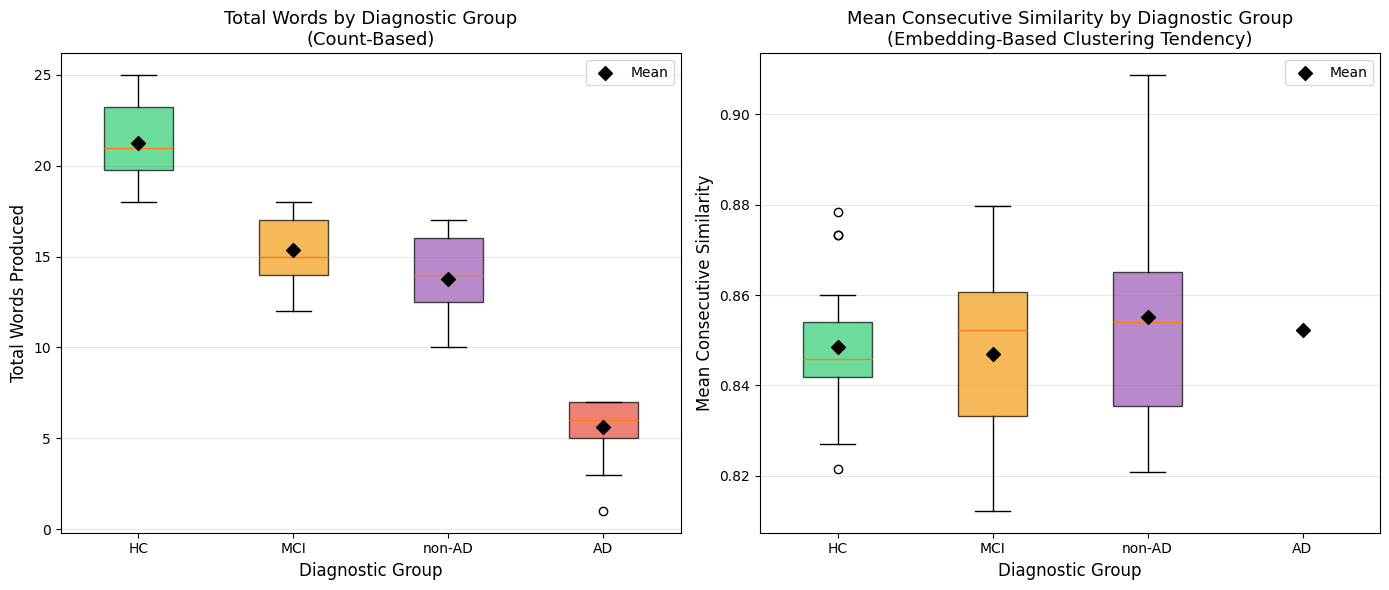

Boxplot saved to data/processed/svf_boxplot_by_diagnosis.png


In [6]:
colors = ['#2ecc71', '#f39c12', '#9b59b6', '#e74c3c']  # HC, MCI, non-AD, AD

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Total words (count-based baseline)
ax = axes[0]
data_total = [scored[scored['diagnosis'] == d]['total_words'].values for d in diag_order]
bp1 = ax.boxplot(data_total, labels=diag_order, patch_artist=True)
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
means = [np.mean(d) for d in data_total]
ax.scatter(range(1, len(diag_order)+1), means, color='black', marker='D', s=50, zorder=3, label='Mean')
ax.set_ylabel('Total Words Produced', fontsize=12)
ax.set_xlabel('Diagnostic Group', fontsize=12)
ax.set_title('Total Words by Diagnostic Group\n(Count-Based)', fontsize=13)
ax.grid(axis='y', alpha=0.3)
ax.legend()

# Panel 2: Mean consecutive similarity (embedding-based)
ax = axes[1]
data_consec = [scored[scored['diagnosis'] == d]['mean_consecutive_similarity'].values for d in diag_order]
bp2 = ax.boxplot(data_consec, labels=diag_order, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
means2 = [np.nanmean(d) for d in data_consec]
ax.scatter(range(1, len(diag_order)+1), means2, color='black', marker='D', s=50, zorder=3, label='Mean')
ax.set_ylabel('Mean Consecutive Similarity', fontsize=12)
ax.set_xlabel('Diagnostic Group', fontsize=12)
ax.set_title('Mean Consecutive Similarity by Diagnostic Group\n(Embedding-Based Clustering Tendency)', fontsize=13)
ax.grid(axis='y', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/svf_boxplot_by_diagnosis.png', dpi=150)
plt.show()

print('Boxplot saved to data/processed/svf_boxplot_by_diagnosis.png')

### 3c. Pairwise Similarity and Temporal Gradient by Diagnostic Group

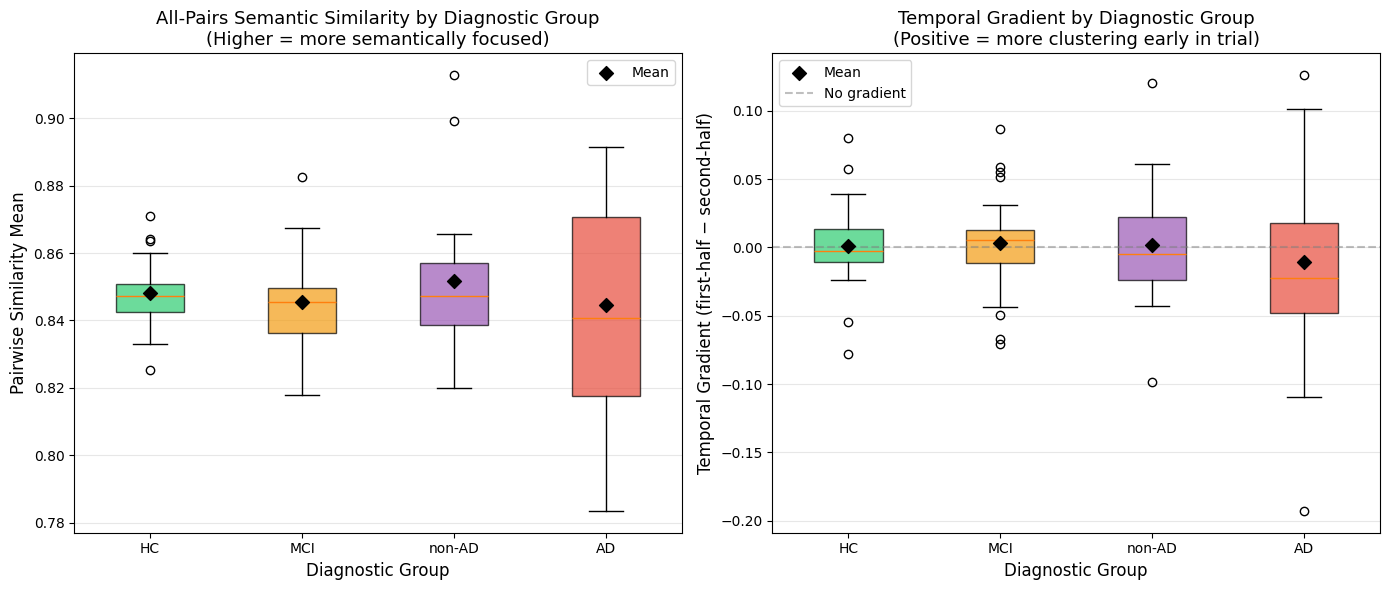

Plot saved to data/processed/svf_embedding_metrics.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Pairwise similarity mean (semantic diversity)
ax = axes[0]
data_pw = [scored[scored['diagnosis'] == d]['pairwise_similarity_mean'].dropna().values for d in diag_order]
bp3 = ax.boxplot(data_pw, labels=diag_order, patch_artist=True)
for patch, color in zip(bp3['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
means3 = [np.nanmean(d) for d in data_pw]
ax.scatter(range(1, len(diag_order)+1), means3, color='black', marker='D', s=50, zorder=3, label='Mean')
ax.set_ylabel('Pairwise Similarity Mean', fontsize=12)
ax.set_xlabel('Diagnostic Group', fontsize=12)
ax.set_title('All-Pairs Semantic Similarity by Diagnostic Group\n(Higher = more semantically focused)', fontsize=13)
ax.grid(axis='y', alpha=0.3)
ax.legend()

# Panel 2: Temporal gradient
ax = axes[1]
data_tg = [scored[scored['diagnosis'] == d]['temporal_gradient'].dropna().values for d in diag_order]
bp4 = ax.boxplot(data_tg, labels=diag_order, patch_artist=True)
for patch, color in zip(bp4['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
means4 = [np.nanmean(d) for d in data_tg]
ax.scatter(range(1, len(diag_order)+1), means4, color='black', marker='D', s=50, zorder=3, label='Mean')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='No gradient')
ax.set_ylabel('Temporal Gradient (first-half − second-half)', fontsize=12)
ax.set_xlabel('Diagnostic Group', fontsize=12)
ax.set_title('Temporal Gradient by Diagnostic Group\n(Positive = more clustering early in trial)', fontsize=13)
ax.grid(axis='y', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/svf_embedding_metrics.png', dpi=150)
plt.show()

print('Plot saved to data/processed/svf_embedding_metrics.png')

### 3d. Scatter: Total Words vs Mean Consecutive Similarity

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

color_map = dict(zip(diag_order, colors))
for diag in diag_order:
    sub = scored[scored['diagnosis'] == diag]
    ax.scatter(
        sub['total_words'],
        sub['mean_consecutive_similarity'],
        c=color_map[diag],
        label=diag,
        alpha=0.7,
        s=60,
        edgecolors='white',
        linewidths=0.5,
    )

ax.set_xlabel('Total Words Produced', fontsize=12)
ax.set_ylabel('Mean Consecutive Similarity', fontsize=12)
ax.set_title(
    'Total Words vs Consecutive Similarity by Diagnostic Group\n'
    '(Count-based productivity vs embedding-based clustering)', fontsize=13
)
ax.legend(title='Diagnosis')
ax.grid(alpha=0.3)

# Correlation
valid = scored[['total_words', 'mean_consecutive_similarity']].dropna()
r = np.corrcoef(valid['total_words'], valid['mean_consecutive_similarity'])[0, 1]
ax.text(0.05, 0.95, f'r = {r:.3f}', transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../data/processed/svf_scatter_words_vs_similarity.png', dpi=150)
plt.show()

print(f'Correlation(total_words, mean_consecutive_similarity): r = {r:.3f}')

### 3e. Example Participants: Consecutive Similarity Profiles

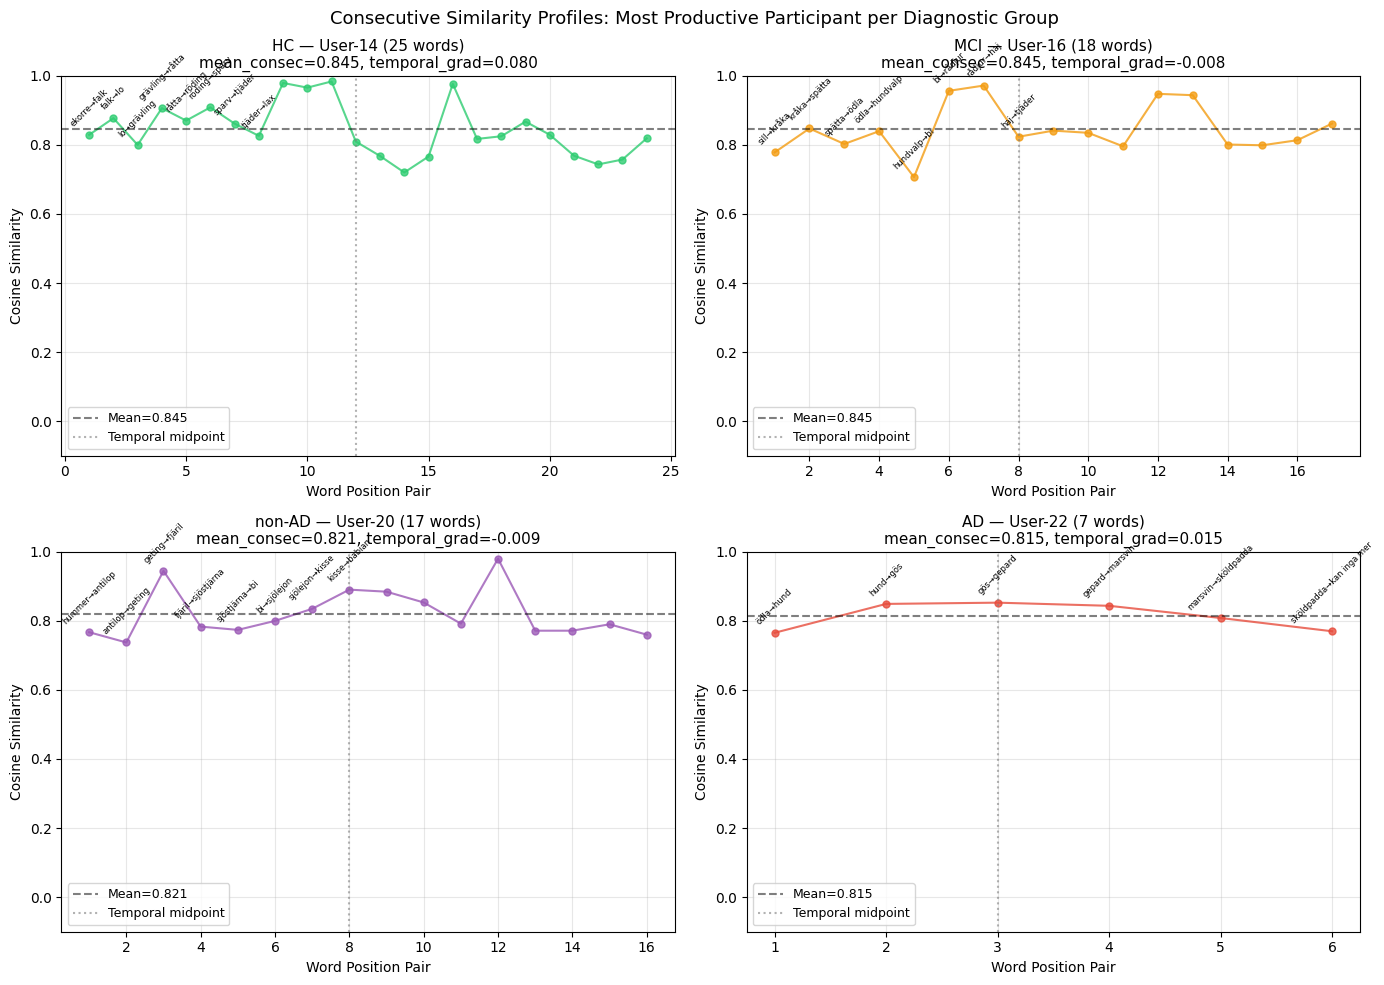

Profile plots saved to data/processed/svf_consec_profiles.png


In [8]:
# Re-score a few participants to extract per-pair similarities for visualization
# Select one participant per diagnostic group with most words (most interesting profile)
example_participants = {}
for diag in diag_order:
    sub_ids = scored[scored['diagnosis'] == diag].sort_values('total_words', ascending=False)['participant_id']
    if len(sub_ids) > 0:
        pid = sub_ids.iloc[0]
        p = next(x for x in participants if x['participant_id'] == pid)
        example_participants[diag] = p

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (diag, color) in zip(axes, zip(diag_order, colors)):
    if diag not in example_participants:
        ax.set_visible(False)
        continue
    
    p = example_participants[diag]
    metrics = score_svf(responses=p['responses'], encoder=encoder)
    consec = metrics['consecutive_similarities']
    
    ax.plot(range(1, len(consec)+1), consec, 'o-', color=color, alpha=0.8, markersize=5)
    ax.axhline(y=np.mean(consec), color='black', linestyle='--', alpha=0.5,
               label=f'Mean={np.mean(consec):.3f}')
    
    # Mark the temporal midpoint
    mid = len(consec) // 2
    if mid > 0:
        ax.axvline(x=mid, color='gray', linestyle=':', alpha=0.6, label='Temporal midpoint')
    
    # Annotate word transitions
    responses = p['responses']
    for i, sim in enumerate(consec[:min(8, len(consec))]):
        ax.annotate(
            f'{responses[i]}→{responses[i+1]}',
            (i+1, sim),
            textcoords='offset points',
            xytext=(0, 6),
            fontsize=6,
            ha='center',
            rotation=45,
        )
    
    ax.set_xlabel('Word Position Pair', fontsize=10)
    ax.set_ylabel('Cosine Similarity', fontsize=10)
    ax.set_title(
        f'{diag} — {p["participant_id"]} ({len(p["responses"])} words)\n'
        f'mean_consec={np.mean(consec):.3f}, temporal_grad={metrics["temporal_gradient"]:.3f}',
        fontsize=11
    )
    ax.set_ylim(-0.1, 1.0)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle('Consecutive Similarity Profiles: Most Productive Participant per Diagnostic Group', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/svf_consec_profiles.png', dpi=150)
plt.show()

print('Profile plots saved to data/processed/svf_consec_profiles.png')

## 4. Save Results

In [9]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
scored.to_csv(OUTPUT_PATH, index=False)
print(f'Saved {len(scored)} participant records to {OUTPUT_PATH}')

summary_path = OUTPUT_PATH.parent / 'svf_summary_by_diagnosis.csv'
summary_df.to_csv(summary_path, index=False)
print(f'Saved summary table to {summary_path}')

Saved 100 participant records to ../data/processed/svf_scored_results.csv
Saved summary table to ../data/processed/svf_summary_by_diagnosis.csv


## 5. Model Comparison: KB-BERT vs SBERT-Swedish

Compare embedding metrics from KB-BERT (CLS-pooling, baseline) and Swedish SBERT
(`KBLab/sentence-bert-swedish-cased`, sentence-level model) across diagnostic groups.

**Tests applied per model × metric:**
- **Kruskal-Wallis H** — non-parametric omnibus test across all 4 groups (HC/MCI/non-AD/AD); p < 0.05 indicates at least one group differs.
- **Cohen's d** — standardized effect size for all pairwise group comparisons; emphasises HC vs AD as the most clinically contrasted pair.

In [10]:
from thesis_project.embeddings.encoder import SentenceTransformerEmbedder

print('Loading SBERT-Swedish...')
sbert_encoder = SentenceTransformerEmbedder('KBLab/sentence-bert-swedish-cased')
print('SBERT-Swedish loaded.')

sbert_records = []
for i, p in enumerate(participants):
    metrics = score_svf(responses=p['responses'], encoder=sbert_encoder)
    sbert_records.append({
        'participant_id': p['participant_id'],
        'diagnosis': p['diagnosis'],
        'age': p['age'],
        'gender': p['gender'],
        'total_words': metrics['total_words'],
        'unique_words': metrics['unique_words'],
        'repetitions': metrics['repetitions'],
        'mean_consecutive_similarity': metrics['mean_consecutive_similarity'],
        'pairwise_similarity_mean': metrics['pairwise_similarity_mean'],
        'temporal_gradient': metrics['temporal_gradient'],
    })
    if (i + 1) % 20 == 0 or (i + 1) == len(participants):
        print(f'  Scored {i+1}/{len(participants)} participants')

sbert_scored = pd.DataFrame(sbert_records)
print(f'\nSBERT scoring complete. Shape: {sbert_scored.shape}')
print(f'Mean consecutive_similarity: {sbert_scored["mean_consecutive_similarity"].mean():.4f}')

Loading SBERT-Swedish...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: KBLab/sentence-bert-swedish-cased
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SBERT-Swedish loaded.
  Scored 20/100 participants
  Scored 40/100 participants
  Scored 60/100 participants
  Scored 80/100 participants
  Scored 100/100 participants

SBERT scoring complete. Shape: (100, 10)
Mean consecutive_similarity: 0.5419


### 5a. Kruskal-Wallis: Group Differences per Model and Metric

In [11]:
from scipy import stats

embedding_metrics = [
    'mean_consecutive_similarity',
    'pairwise_similarity_mean',
    'temporal_gradient',
]
metric_labels = {
    'mean_consecutive_similarity': 'Consecutive Sim',
    'pairwise_similarity_mean':     'Pairwise Sim',
    'temporal_gradient':            'Temporal Gradient',
}

models = {'KB-BERT (CLS)': scored, 'SBERT-Swedish': sbert_scored}

kw_rows = []
for model_name, df in models.items():
    for metric in embedding_metrics:
        groups = [df[df['diagnosis'] == d][metric].dropna().values for d in diag_order]
        groups = [g for g in groups if len(g) > 1]
        stat, p = stats.kruskal(*groups)
        kw_rows.append({
            'Model':       model_name,
            'Metric':      metric_labels[metric],
            'H':           round(stat, 3),
            'p':           round(p, 4),
            'Significant': 'yes' if p < 0.05 else 'no',
        })

kw_df = pd.DataFrame(kw_rows)
print('Kruskal-Wallis H-test — Group Differences Across HC / MCI / non-AD / AD')
print('=' * 65)
print(kw_df.to_string(index=False))

Kruskal-Wallis H-test — Group Differences Across HC / MCI / non-AD / AD
        Model            Metric      H      p Significant
KB-BERT (CLS)   Consecutive Sim  0.770 0.8567          no
KB-BERT (CLS)      Pairwise Sim  0.851 0.8372          no
KB-BERT (CLS) Temporal Gradient  0.959 0.8113          no
SBERT-Swedish   Consecutive Sim  8.278 0.0406         yes
SBERT-Swedish      Pairwise Sim 11.080 0.0113         yes
SBERT-Swedish Temporal Gradient  2.531 0.4697          no


### 5b. Cohen's d: Pairwise Group Comparisons per Model

Positive d means Group 1 > Group 2 on the metric.
Magnitude thresholds: |d| ≥ 0.8 large, ≥ 0.5 medium, ≥ 0.2 small, < 0.2 negligible.

In [12]:
def cohens_d(a, b):
    """Pooled-SD Cohen's d."""
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2:
        return np.nan
    pooled_std = np.sqrt(
        ((n1 - 1) * a.std(ddof=1) ** 2 + (n2 - 1) * b.std(ddof=1) ** 2)
        / (n1 + n2 - 2)
    )
    if pooled_std == 0:
        return np.nan
    return (a.mean() - b.mean()) / pooled_std


def magnitude(d):
    d = abs(d)
    if np.isnan(d): return 'n/a'
    if d >= 0.8:    return 'large'
    if d >= 0.5:    return 'medium'
    if d >= 0.2:    return 'small'
    return 'negligible'


pairs = [('HC', 'MCI'), ('HC', 'non-AD'), ('HC', 'AD'), ('MCI', 'AD')]

cd_rows = []
for model_name, df in models.items():
    for metric in embedding_metrics:
        for g1, g2 in pairs:
            a = df[df['diagnosis'] == g1][metric].values
            b = df[df['diagnosis'] == g2][metric].values
            d = cohens_d(a, b)
            cd_rows.append({
                'Model':     model_name,
                'Metric':    metric_labels[metric],
                'G1':        g1,
                'G2':        g2,
                "d":         round(d, 3),
                'Magnitude': magnitude(d),
            })

cd_df = pd.DataFrame(cd_rows)
print("Cohen's d — Pairwise Group Comparisons (positive d = G1 > G2)")
print('=' * 70)
print(cd_df.to_string(index=False))

Cohen's d — Pairwise Group Comparisons (positive d = G1 > G2)
        Model            Metric  G1     G2      d  Magnitude
KB-BERT (CLS)   Consecutive Sim  HC    MCI  0.089 negligible
KB-BERT (CLS)   Consecutive Sim  HC non-AD -0.360      small
KB-BERT (CLS)   Consecutive Sim  HC     AD -0.129 negligible
KB-BERT (CLS)   Consecutive Sim MCI     AD -0.173 negligible
KB-BERT (CLS)      Pairwise Sim  HC    MCI  0.238      small
KB-BERT (CLS)      Pairwise Sim  HC non-AD -0.219      small
KB-BERT (CLS)      Pairwise Sim  HC     AD  0.174 negligible
KB-BERT (CLS)      Pairwise Sim MCI     AD  0.045 negligible
KB-BERT (CLS) Temporal Gradient  HC    MCI -0.049 negligible
KB-BERT (CLS) Temporal Gradient  HC non-AD -0.002 negligible
KB-BERT (CLS) Temporal Gradient  HC     AD  0.234      small
KB-BERT (CLS) Temporal Gradient MCI     AD  0.266      small
SBERT-Swedish   Consecutive Sim  HC    MCI  0.403      small
SBERT-Swedish   Consecutive Sim  HC non-AD  0.633     medium
SBERT-Swedish   Consecu

### 5c. Visualisations: Metric Distributions and Effect Sizes

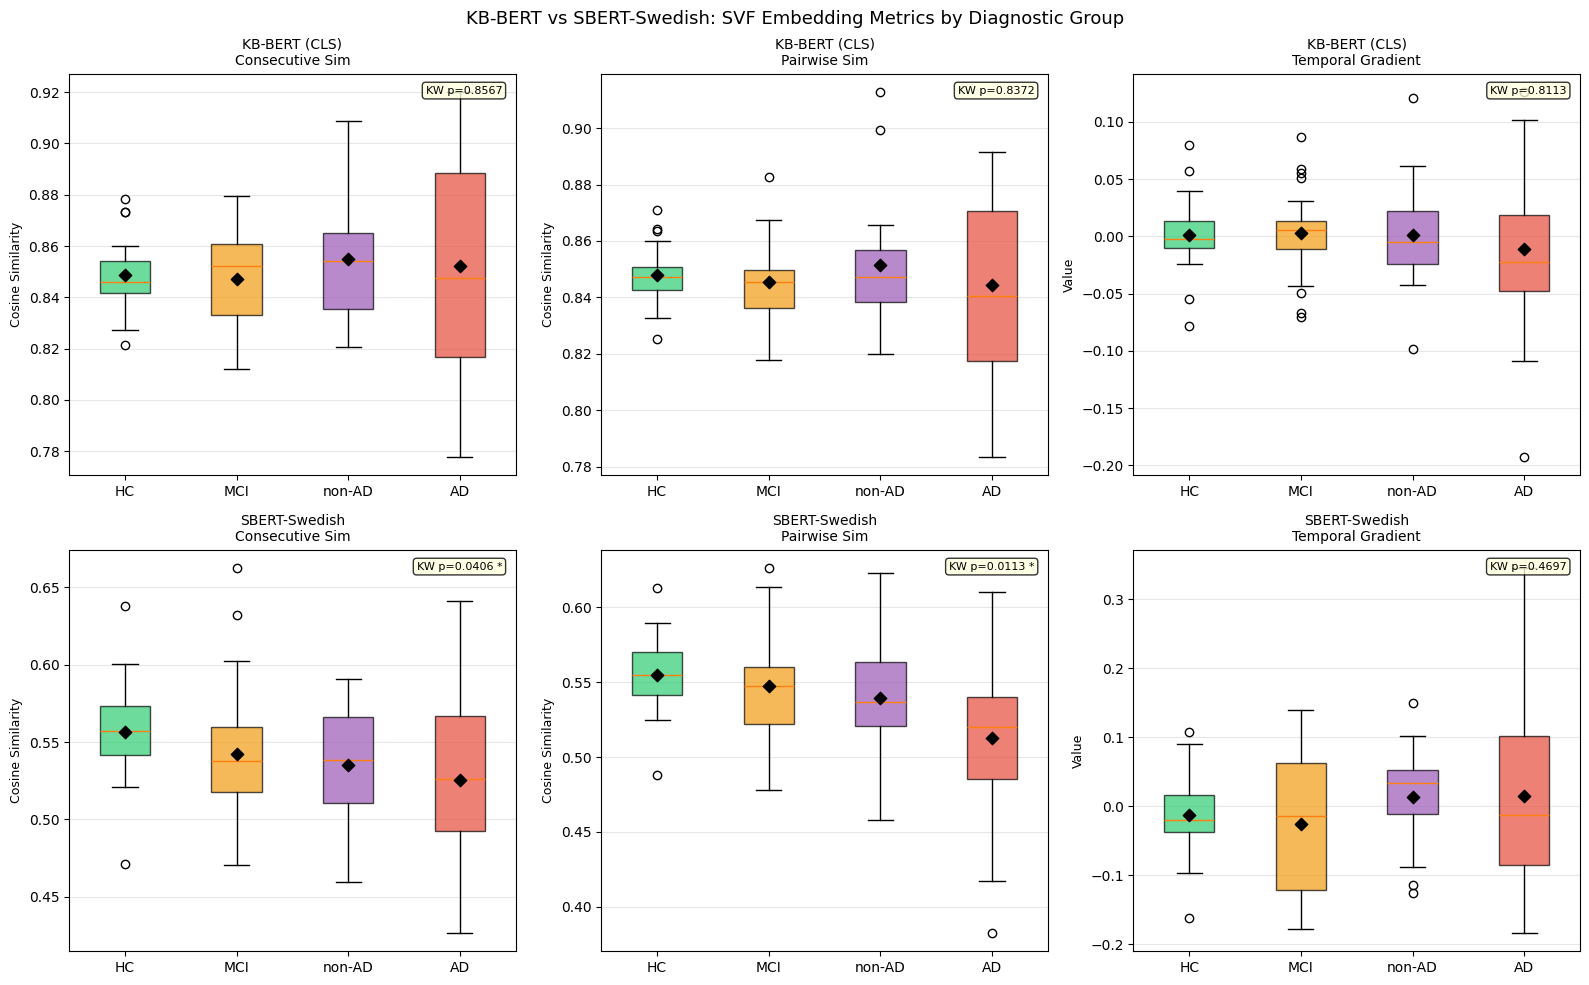

Saved svf_model_comparison.png


In [13]:
colors = ['#2ecc71', '#f39c12', '#9b59b6', '#e74c3c']  # HC, MCI, non-AD, AD

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for row_idx, (model_name, df) in enumerate(models.items()):
    for col_idx, metric in enumerate(embedding_metrics):
        ax = axes[row_idx, col_idx]
        data_by_group = [
            df[df['diagnosis'] == d][metric].dropna().values for d in diag_order
        ]
        bp = ax.boxplot(data_by_group, labels=diag_order, patch_artist=True)
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        means = [np.nanmean(d) if len(d) else np.nan for d in data_by_group]
        ax.scatter(range(1, len(diag_order) + 1), means,
                   color='black', marker='D', s=40, zorder=3)
        ax.set_title(f'{model_name}\n{metric_labels[metric]}', fontsize=10)
        ylabel = 'Cosine Similarity' if 'similarity' in metric else 'Value'
        ax.set_ylabel(ylabel, fontsize=9)
        ax.grid(axis='y', alpha=0.3)

        row = kw_df[
            (kw_df['Model'] == model_name) & (kw_df['Metric'] == metric_labels[metric])
        ]
        if not row.empty:
            p_val = row['p'].values[0]
            label = f'KW p={p_val:.4f}' + (' *' if p_val < 0.05 else '')
            ax.text(0.97, 0.97, label, transform=ax.transAxes, fontsize=8,
                    ha='right', va='top',
                    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle(
    'KB-BERT vs SBERT-Swedish: SVF Embedding Metrics by Diagnostic Group',
    fontsize=13,
)
plt.tight_layout()
plt.savefig('../data/processed/svf_model_comparison.png', dpi=150)
plt.show()
print('Saved svf_model_comparison.png')

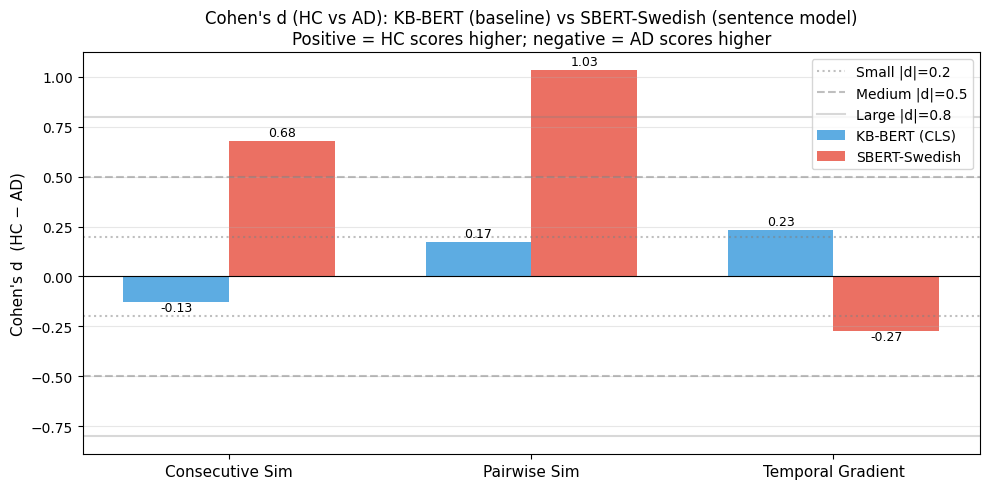

Saved svf_cohens_d_comparison.png


In [14]:
# Bar chart: Cohen's d for HC vs AD — the most clinically contrasted pair
hc_ad = cd_df[cd_df['G2'] == 'AD'].copy()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(embedding_metrics))
width = 0.35
model_styles = [
    ('KB-BERT (CLS)',  '#3498db'),
    ('SBERT-Swedish', '#e74c3c'),
]

for i, (model_name, bar_color) in enumerate(model_styles):
    vals = [
        hc_ad[
            (hc_ad['Model'] == model_name) &
            (hc_ad['Metric'] == metric_labels[m]) &
            (hc_ad['G1'] == 'HC')
        ]['d'].values[0]
        for m in embedding_metrics
    ]
    bars = ax.bar(x + (i - 0.5) * width, vals, width,
                  label=model_name, color=bar_color, alpha=0.8)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (0.01 if val >= 0 else -0.06),
                f'{val:.2f}', ha='center', va='bottom', fontsize=9,
            )

ax.axhline(0,   color='black', linewidth=0.8)
ax.axhline( 0.2, color='gray', linestyle=':',  alpha=0.5, label='Small |d|=0.2')
ax.axhline( 0.5, color='gray', linestyle='--', alpha=0.5, label='Medium |d|=0.5')
ax.axhline( 0.8, color='gray', linestyle='-',  alpha=0.3, label='Large |d|=0.8')
ax.axhline(-0.2, color='gray', linestyle=':',  alpha=0.5)
ax.axhline(-0.5, color='gray', linestyle='--', alpha=0.5)
ax.axhline(-0.8, color='gray', linestyle='-',  alpha=0.3)

ax.set_xticks(x)
ax.set_xticklabels([metric_labels[m] for m in embedding_metrics], fontsize=11)
ax.set_ylabel("Cohen's d  (HC − AD)", fontsize=11)
ax.set_title(
    "Cohen's d (HC vs AD): KB-BERT (baseline) vs SBERT-Swedish (sentence model)\n"
    "Positive = HC scores higher; negative = AD scores higher",
    fontsize=12,
)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/svf_cohens_d_comparison.png', dpi=150)
plt.show()
print("Saved svf_cohens_d_comparison.png")

## Key Takeaways

1. **Count-based vs embedding-based**: `total_words` captures overall productivity (the standard clinical measure), while `mean_consecutive_similarity` captures *how* words were organized — clustering by semantic category vs switching.

2. **Consecutive similarity**: Higher values indicate the participant named semantically similar animals in sequence (e.g., farm animals → dog → cat → rabbit). Lower values indicate more switching between categories.

3. **Pairwise similarity**: Captures overall semantic breadth of the response set. Lower pairwise similarity = greater semantic diversity across named animals.

4. **Temporal gradient**: Positive gradient means more clustering early in the trial (typical when semantic memory is intact); negative gradient may reflect strategy breakdown.

5. **Correlation**: The scatter plot reveals whether total productivity and clustering tendency are independent — if they correlate strongly, embedding metrics may not add information beyond counts.